# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **Preparation**

このセクションでは前のChapterの内容を読み込むだけです。<br>
コードを実行するだけでOK。読まなくても大丈夫です。<br>
気軽に先へ進んでください。<br>

In [ ]:
# ファイルをダウンロードしてください
!wget https://raw.githubusercontent.com/HayatoHongo/EveryonesLLM/main/input.txt -O input.txt
# utf-8でダウンロードしたinput.textファイルを読み込む。
with open("input.txt", 'r', encoding = 'utf-8') as f:
    text = f.read()

# テンソルを見やすく表示する関数（任意）
import torch
import torch.nn as nn
import torch.nn.functional as F

# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# Pytorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor


--2025-11-14 09:57:32--  https://raw.githubusercontent.com/HayatoHongo/EveryonesLLM/main/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.03s   

2025-11-14 09:57:32 (32.6 MB/s) - ‘input.txt’ saved [1115394/1115394]



# **Chapter 17: データセットを大きくする**



### **Section 1: Common Crawl & FineWeb**

モデルの **loss plateau** を下げるために、パラメータを増やします。

しかし、パラメータを増やすと過学習しやすくなるため、**もっと大量のテキストデータ** も必要です。

では、世界最大のテキストデータセットは何でしょう？


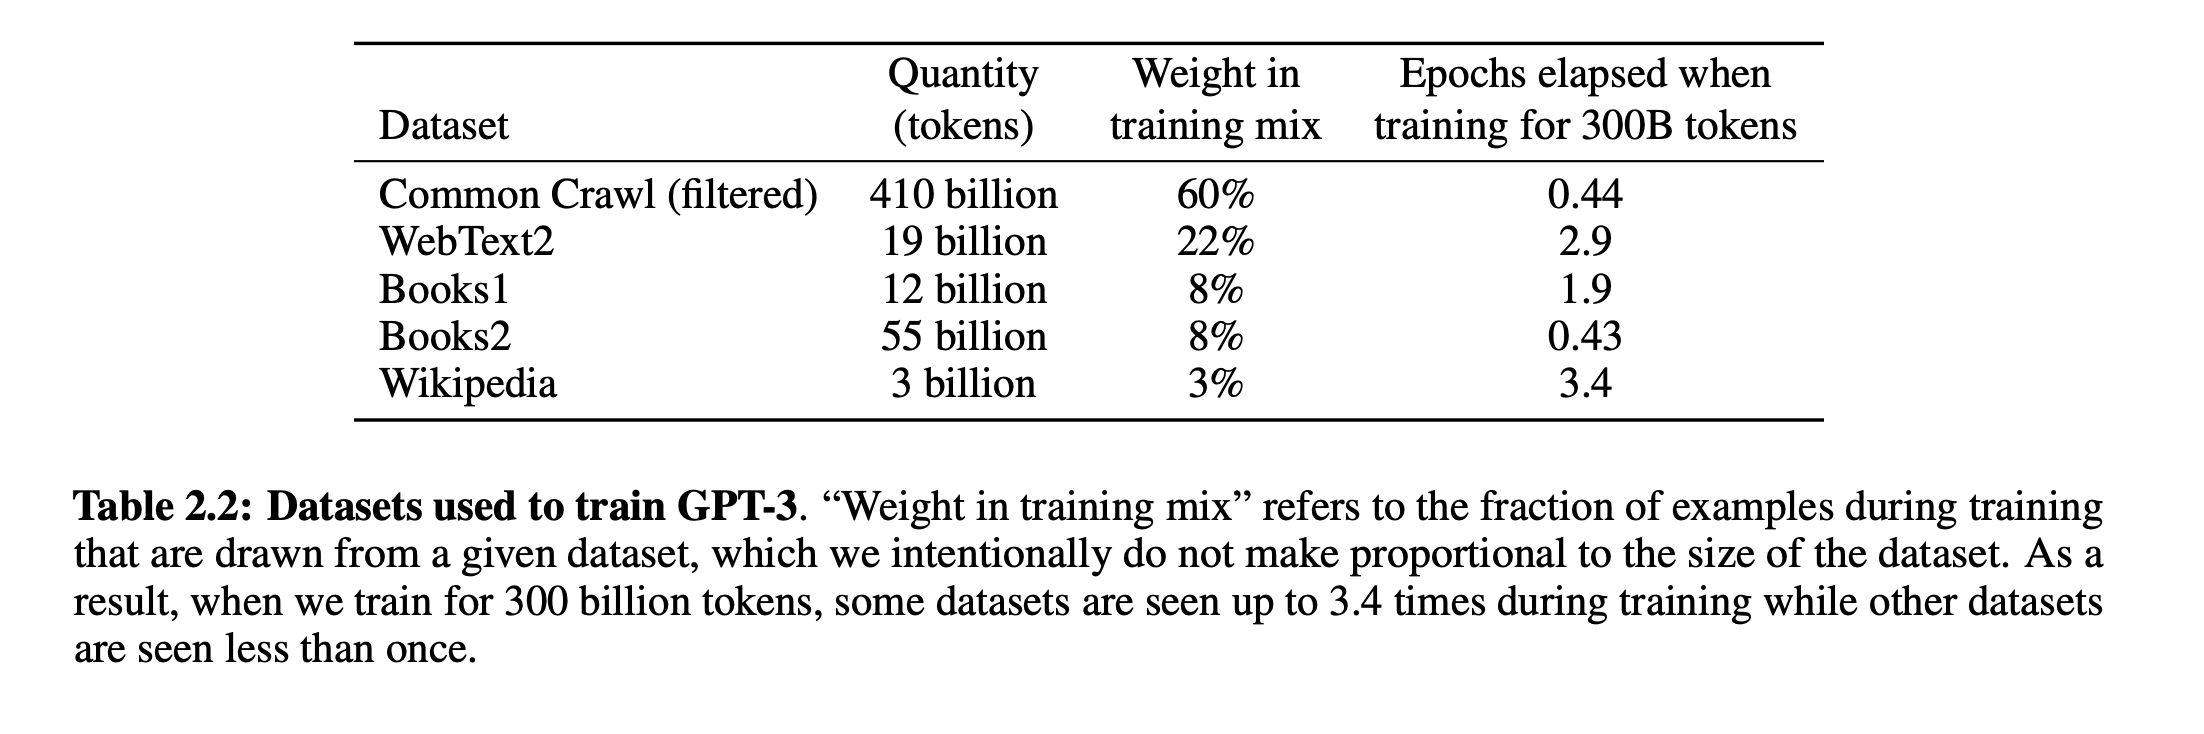

出典：Brown, T. B., Mann, B., Ryder, N., Subbiah, M., Kaplan, J., Dhariwal, P., … Amodei, D. (2020). *Language Models are Few-Shot Learners.* arXiv:2005.14165. [https://arxiv.org/abs/2005.14165](https://arxiv.org/abs/2005.14165)


なお、Common Crawlには3種類のデータ形式があります


| 形式 | 内容 | 用途 |
|------|------|------|
| **WARC** | HTML・画像を含む生データ | 全文解析・アーカイブ |
| **WET** | テキストのみ抽出 | NLP・言語モデル訓練 |
| **WAT** | メタデータ（リンク・HTTP情報など） | 構造解析・リンク解析 |


⬇️ 以下のリンクでWET形式のサンプルが公開されています

https://huggingface.co/datasets/agentlans/common-crawl-sample/



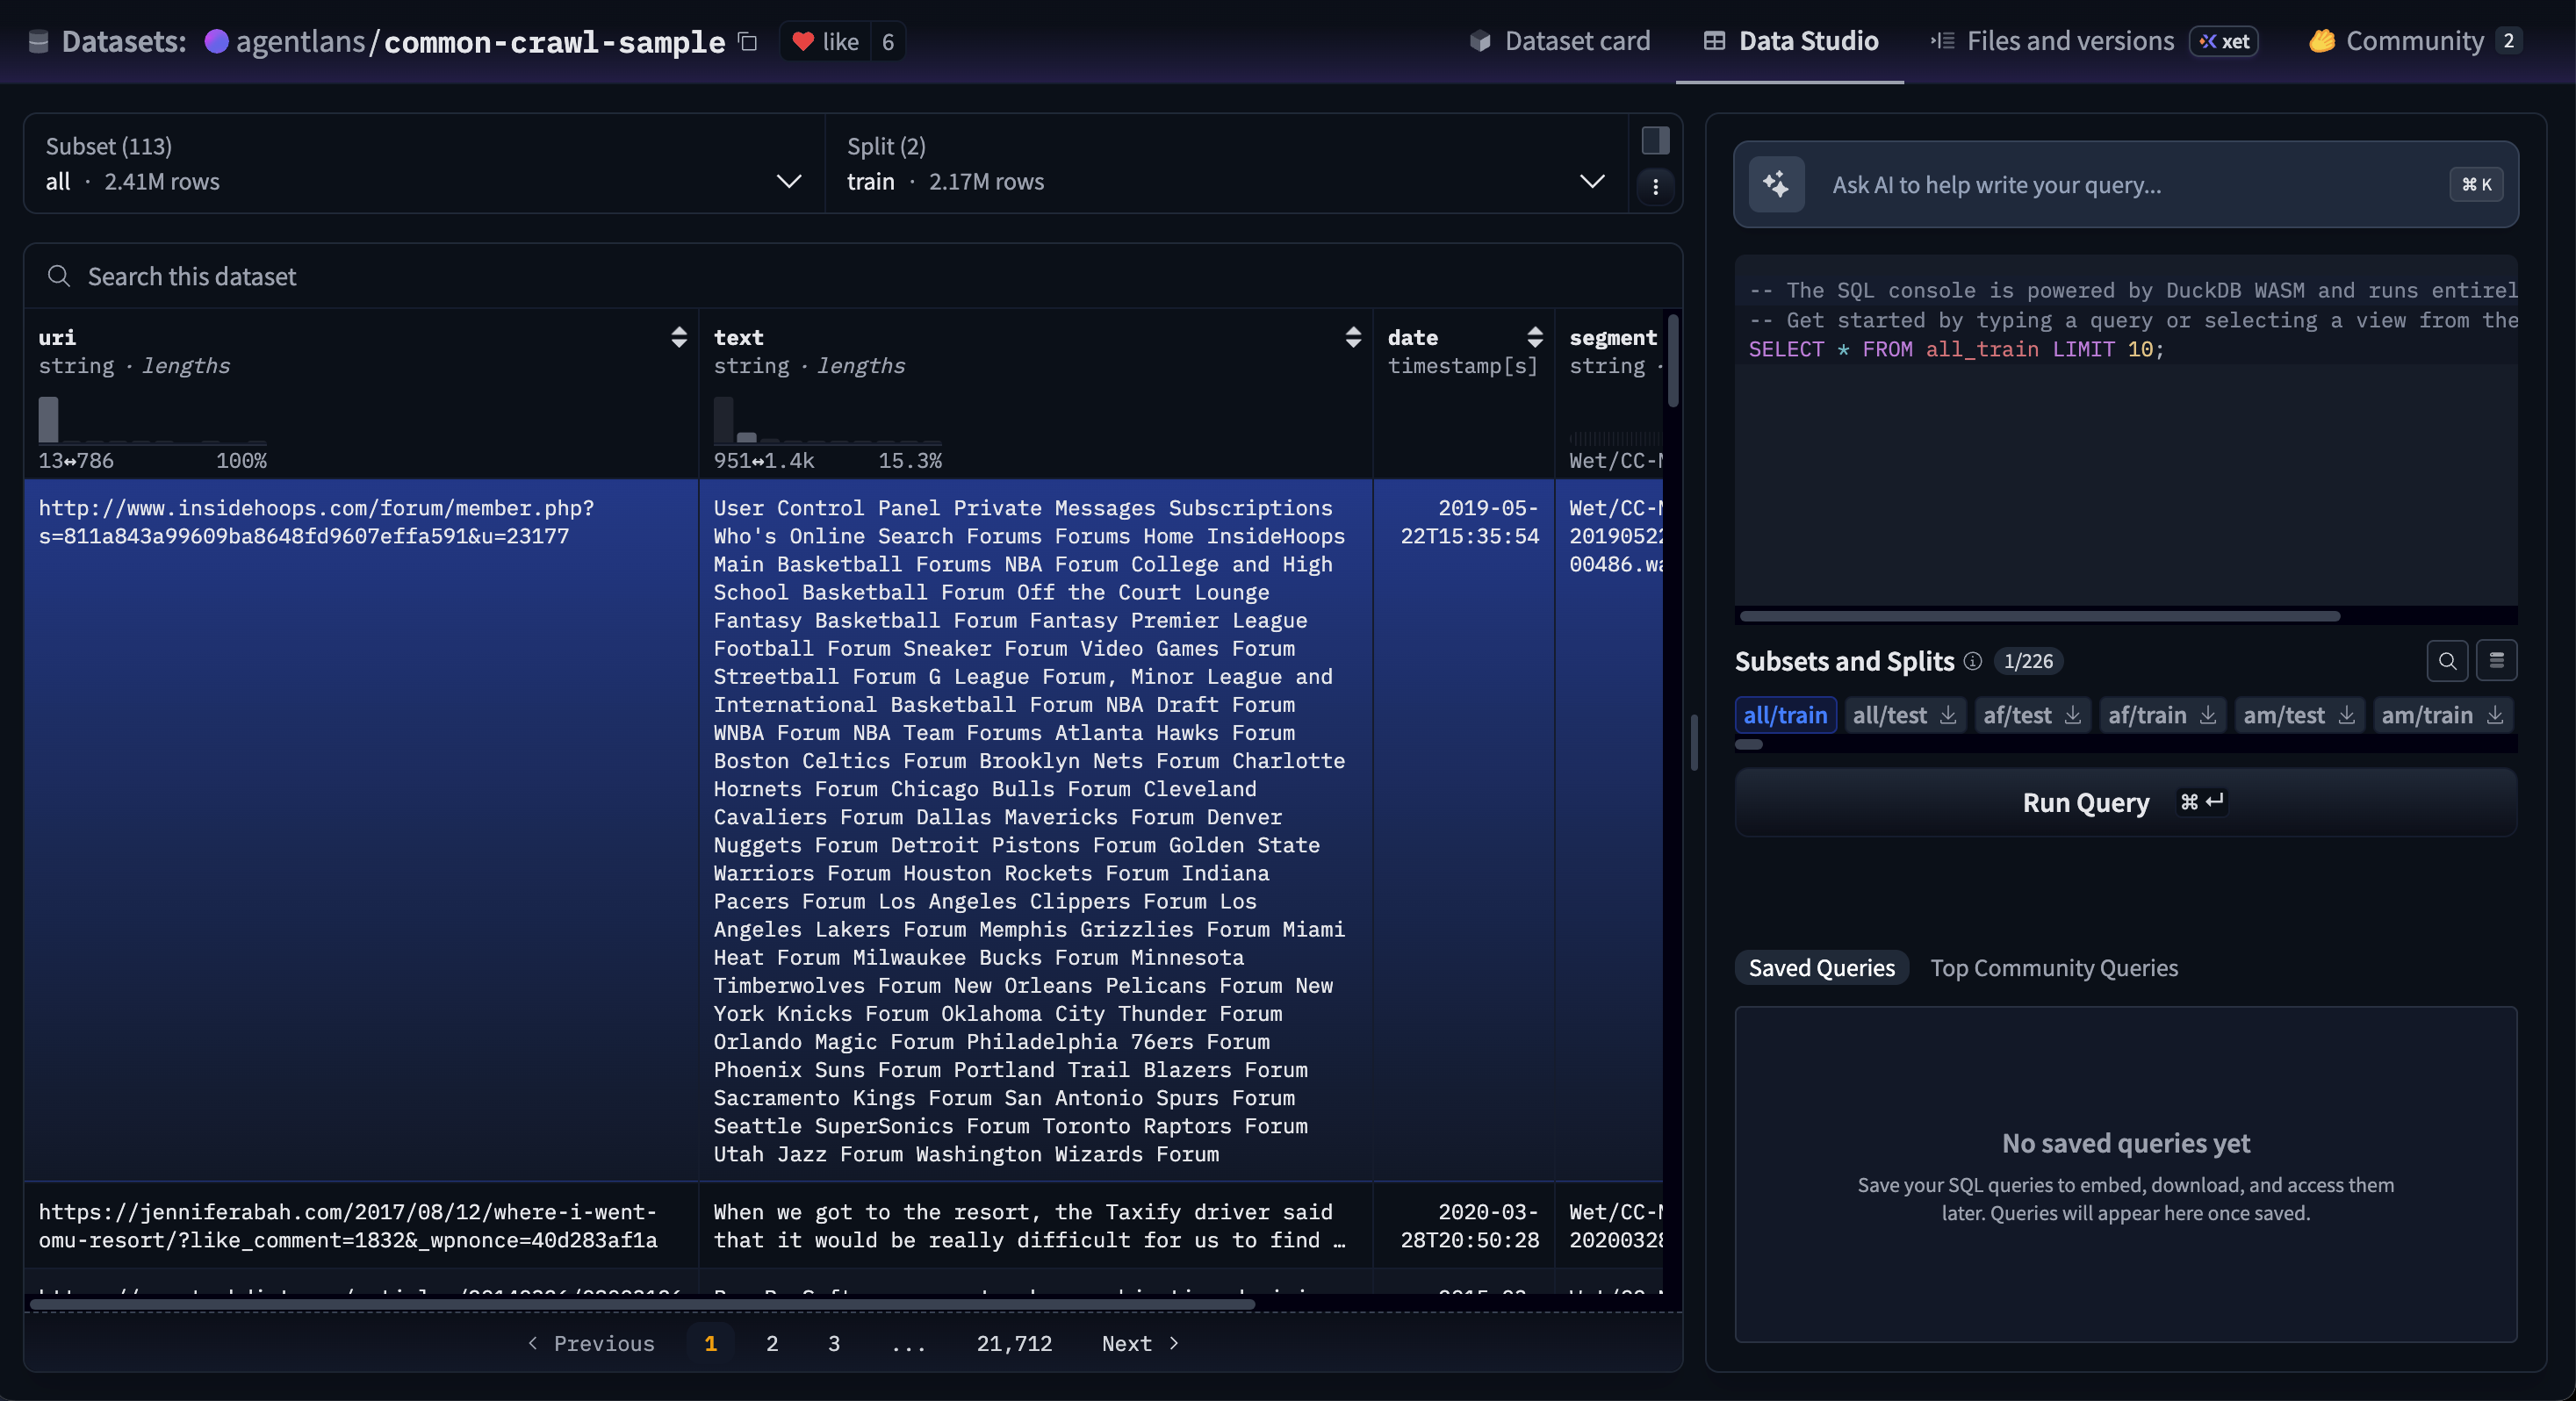

#### Common Crawl とテキストフィルタリングのお話

```plain
User Control Panel Private Messages Subscriptions Who's Online Search …
```

Common Crawl は Webデータ由来なので、上記のような文章とは言えないテキストが山ほど含まれています。

そのままでは言語モデルの学習には向かないため、GPT-3 を訓練した際には **厳しいフィルタリング** が行われ、

“良質な文章”だけが選び抜かれました。ただ、フィルタ済みテキストコーパスは一般公開されていません。

「フィルタ済みデータがほしいよ、、、😭」

そこに現れた救世主が Hugging Face の *fineweb* です。


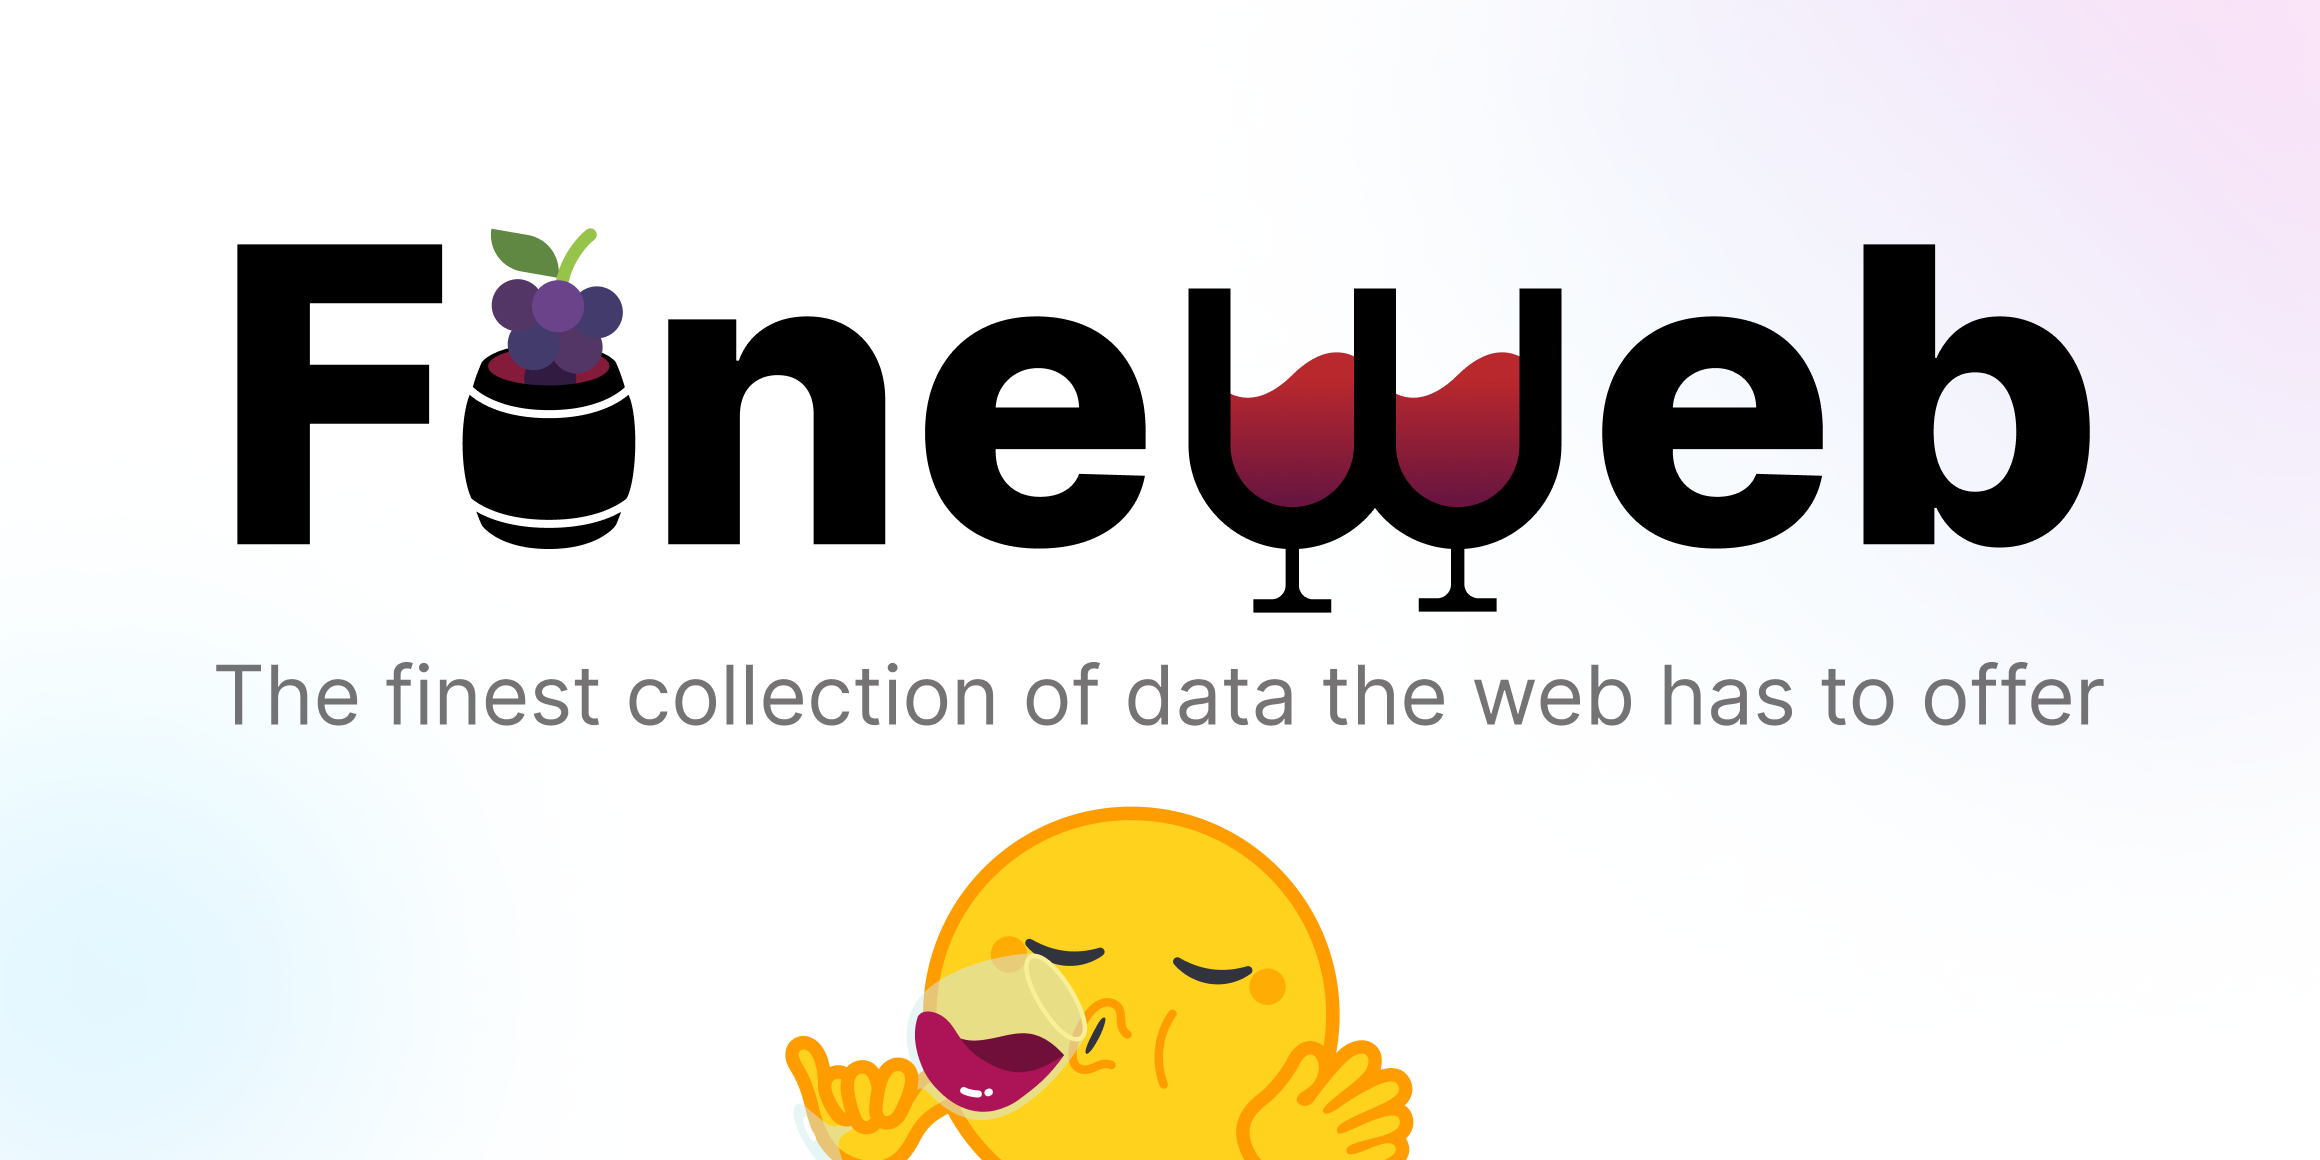

出典：https://huggingface.co/datasets/HuggingFaceFW/fineweb

この  **fineweb データセット**のおかげで、私たちもフィルタ済みテキストを手軽に利用できます。  

⬇️ データセットはこちら  
https://huggingface.co/datasets/HuggingFaceFW/fineweb

- ディスクサイズは **108TB**（ペタバイト級のCommon Crawl よりはかなりスリム！）  
- とはいえ巨大なので、今回はその一部だけを使います

#### finewebデータを自分で触ってみよう！

ハンズオン動画を見ながら、実際に自分で動画の通りに手を動かしてみてください。

スマホのYouTubeアプリで`EveryonesLLM see fineweb dataset on huggingface` というキーワードで検索すると、

スマホで動画を見ながら自分で手を動かすことができます。

なお、切実にデュアルディスプレイの購入をおすすめします。

📺 [動画を見る](https://youtu.be/up6209gzwl0)  
- 再生時間：6分（音声なし）
- Video ID: up6209gzwl0

⚠️ ハンズオン、絶対にスキップしないでください！

ちゃんと生データを見ることは、Shakespeare の時からのお約束です。

**Section 1: Common Crawl & FineWeb** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: FineWebデータセットをダウンロードしてみる**

早速 fineweb をダウンロードしてみましょう！

<br>

…とはいえ元のデータは 100TB もあり、

とても現実的にダウンロードできるサイズではありません。

<br>

そこで、FineWeb をさらにフィルタして教科書のような知識中心のテキストに絞った **FineWeb-Edu** を使います。
[https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu)

とはいえ、FineWeb-Edu も合計 10TB とまだ大きめです。

<br>

そこで今回は、FineWeb-Edu のサブセットである **sample-10BT**（100億トークン）を使います。

これでも 約25GB と大きめですが、実験には扱いやすいサイズです。

アクセス方法：
`Files and Versions` → `sample` → `10BT`

📺 [動画を見る](https://youtu.be/Q6p2b2I8ZnY)  
- 再生時間：7秒、音声なし  
- Video ID: Q6p2b2I8ZnY

Fineweb のデータセットを、まずはほんの一部だけダウンロードしてみます。

| データセット                | 内容                         | サイズ       | 備考                |
| --------------------- | -------------------------- | --------- | ----------------- |
| **FineWeb**           | Web 全体から集めた大規模データ          | **≈100TB** | 大きすぎて現実的にDL不可     |
| **FineWeb-Edu**       | FineWeb を教育的テキストにフィルタ      | **≈10TB**  | まだ巨大              |
| **sample-10BT**       | FineWeb-Edu の 100億トークンサンプル | **≈25GB**  | ここからさらに 1 ファイルを使用 |
| **000_00000.parquet** | sample-10BT 内の個別ファイル（1番目）  | **≈2GB** | 最終的に使用する唯一のファイル   |


最終的に使用するのは、**sample-10BT の中の `000_00000.parquet` だけ**です。


それでは、`000_00000.parquet` をダウンロードするコードを書いていきます。

手順

1. FineWeb-Edu のページを開く
   👉 [https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu)
2. **Files and Versions → sample → 10BT → 000_0000.parquet** を選択
3. ブラウザ上のURLをコピー
4. Colab上にコピーしたURLをペースト



📺 [動画を見る](https://youtu.be/lxbB5_2d7M0)  
- 再生時間：38秒、音声なし  
- Video ID: lxbB5_2d7M0

In [ ]:
browser_data_path = "https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu/blob/main/sample/10BT/000_00000.parquet" # TODO: URL をコピー&ペースト

HuggingFace では、**ブラウザ上で表示される URL と、コードから直接アクセスできる URL が異なります。**

特に、ブラウザの URL に含まれる次の違いに注意してください：

| 種類            | 出現する場所              | 例                                 | 用途                         |
| ------------- | ------------------- | --------------------------------- | -------------------------- |
| **`blob`**    | ブラウザでファイルを開いたときのURL | `/blob/main/.../000_00000.parquet`    | **閲覧用**（ダウンロード API では使えない） |
| **`resolve`** | 実際にコードでアクセスするときのURL | `/resolve/main/.../000_00000.parquet` | **ダウンロード用 / プログラムから使う用**   |


ブラウザ URL に含まれる`blob` を`resolve` に置き換えたURLを作成してください。

In [ ]:
data_file = "https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu/resolve/main/sample/10BT/000_00000.parquet" # TODO: URLの中の`blob`を`resolve`に置き換える

今回は、この外部ファイル `000_00000.parquet` から、自分でデータセットを作成します。

作成されるデータセットは **HuggingFace Datasets ライブラリ独自の `Dataset` クラスのインスタンス**です。

これは Python の通常のリストや辞書でもなく、pandas の DataFrame とも異なる専用のデータ構造です。

```python
関数: load_dataset
引数: path="parquet", data_files=data_file, split="train", cache_dir="/content/fineweb"
```

* `load_dataset()` は Hugging Face Datasets ライブラリの関数で、指定形式のデータをロードします。
* `path="parquet"` により Parquet 形式のデータ読み込みを指定。
* `data_files` に読み込むファイルパス（変数）を渡す。
* `split="train"` は、外部ファイル（Parquet など）から 自分で Dataset を作るときに割り当てる任意の split 名 です（train / val など自由に設定できます）。今回のように**外部ファイルから自作するのはイレギュラーなので、通常は不要です。**
* `cache_dir="/content/fineweb"` は、ダウンロードしたデータのキャッシュ保存先。


⚠️ HuggingFaceの認証トークン`HF_TOKEN`が必要ですと表示されても、キャンセルして大丈夫です。

公開データセットはHuggingFaceの認証トークンがなくてもダウンロードできるからです。

In [ ]:
from datasets import load_dataset
ds = load_dataset("parquet", data_files=data_file, split="train", cache_dir="/content/fineweb") # TODO: load_dataset(path=..., data_files=..., split=..., cache_dir=...)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


sample/10BT/000_00000.parquet:   0%|          | 0.00/2.15G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

これからのデータ取得は、基本的に **HuggingFace から直接ダウンロードする方法が中心**になります。

❌ **ローカル → Colab への直接アップロード** は非推奨です。

理由はシンプルで、1GB のファイルでもアップロードに数十分かかり、実質ムリだからです。

<br>

⭕ **HuggingFace → Colab（今回の方法／おすすめ）**

* 高速ダウンロードでとても快適 ✨

🪄 それでも「どうしてもローカルの大容量ファイルを Colab に置きたい！」場合は？

1. **ローカル → HuggingFace**（1GB でも約 5 分以内）
2. **HuggingFace → Colab** に高速ダウンロード 🎉


`ds`は HuggingFace Datasets ライブラリ独自の `Dataset` クラスのインスタンスになっています。

In [ ]:
ds

Dataset({
    features: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score'],
    num_rows: 726000
})

最初の要素を見てみましょう。

In [ ]:
ds[0]

{'text': 'The Independent Jane\nFor all the love, romance and scandal in Jane Austen’s books, what they are really about is freedom and independence. Independence of thought and the freedom to choose.\nElizabeth’s refusal of Mr. Collins offer of marriage showed an independence seldom seen in heroines of the day. Her refusal of Mr. Darcy while triggered by anger showed a level of independence that left him shocked and stunned.\nThe freedom she exhibited in finally accepting him in direct defiance of Lady Catherine and knowing her father would disapprove was unusual even for Austen. In her last book Anne Elliot is persuaded to refuse Captain Wentworth at Lady Russel’s insistence.\nAlthough Jane played by the rules of the day, all of her writing is infused with how she wanted life to be. She ‘screams’ her outrage at the limitations for women in Emma.\nWhen accosted by Mrs. Elton, Jane Fairfax says,\n“Excuse me, ma’am, but this is by no means my intention; I make no inquiry myself, and sho

[sample-10BT](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu/viewer/sample-10BT)のデータプレビューとも一致していますね。

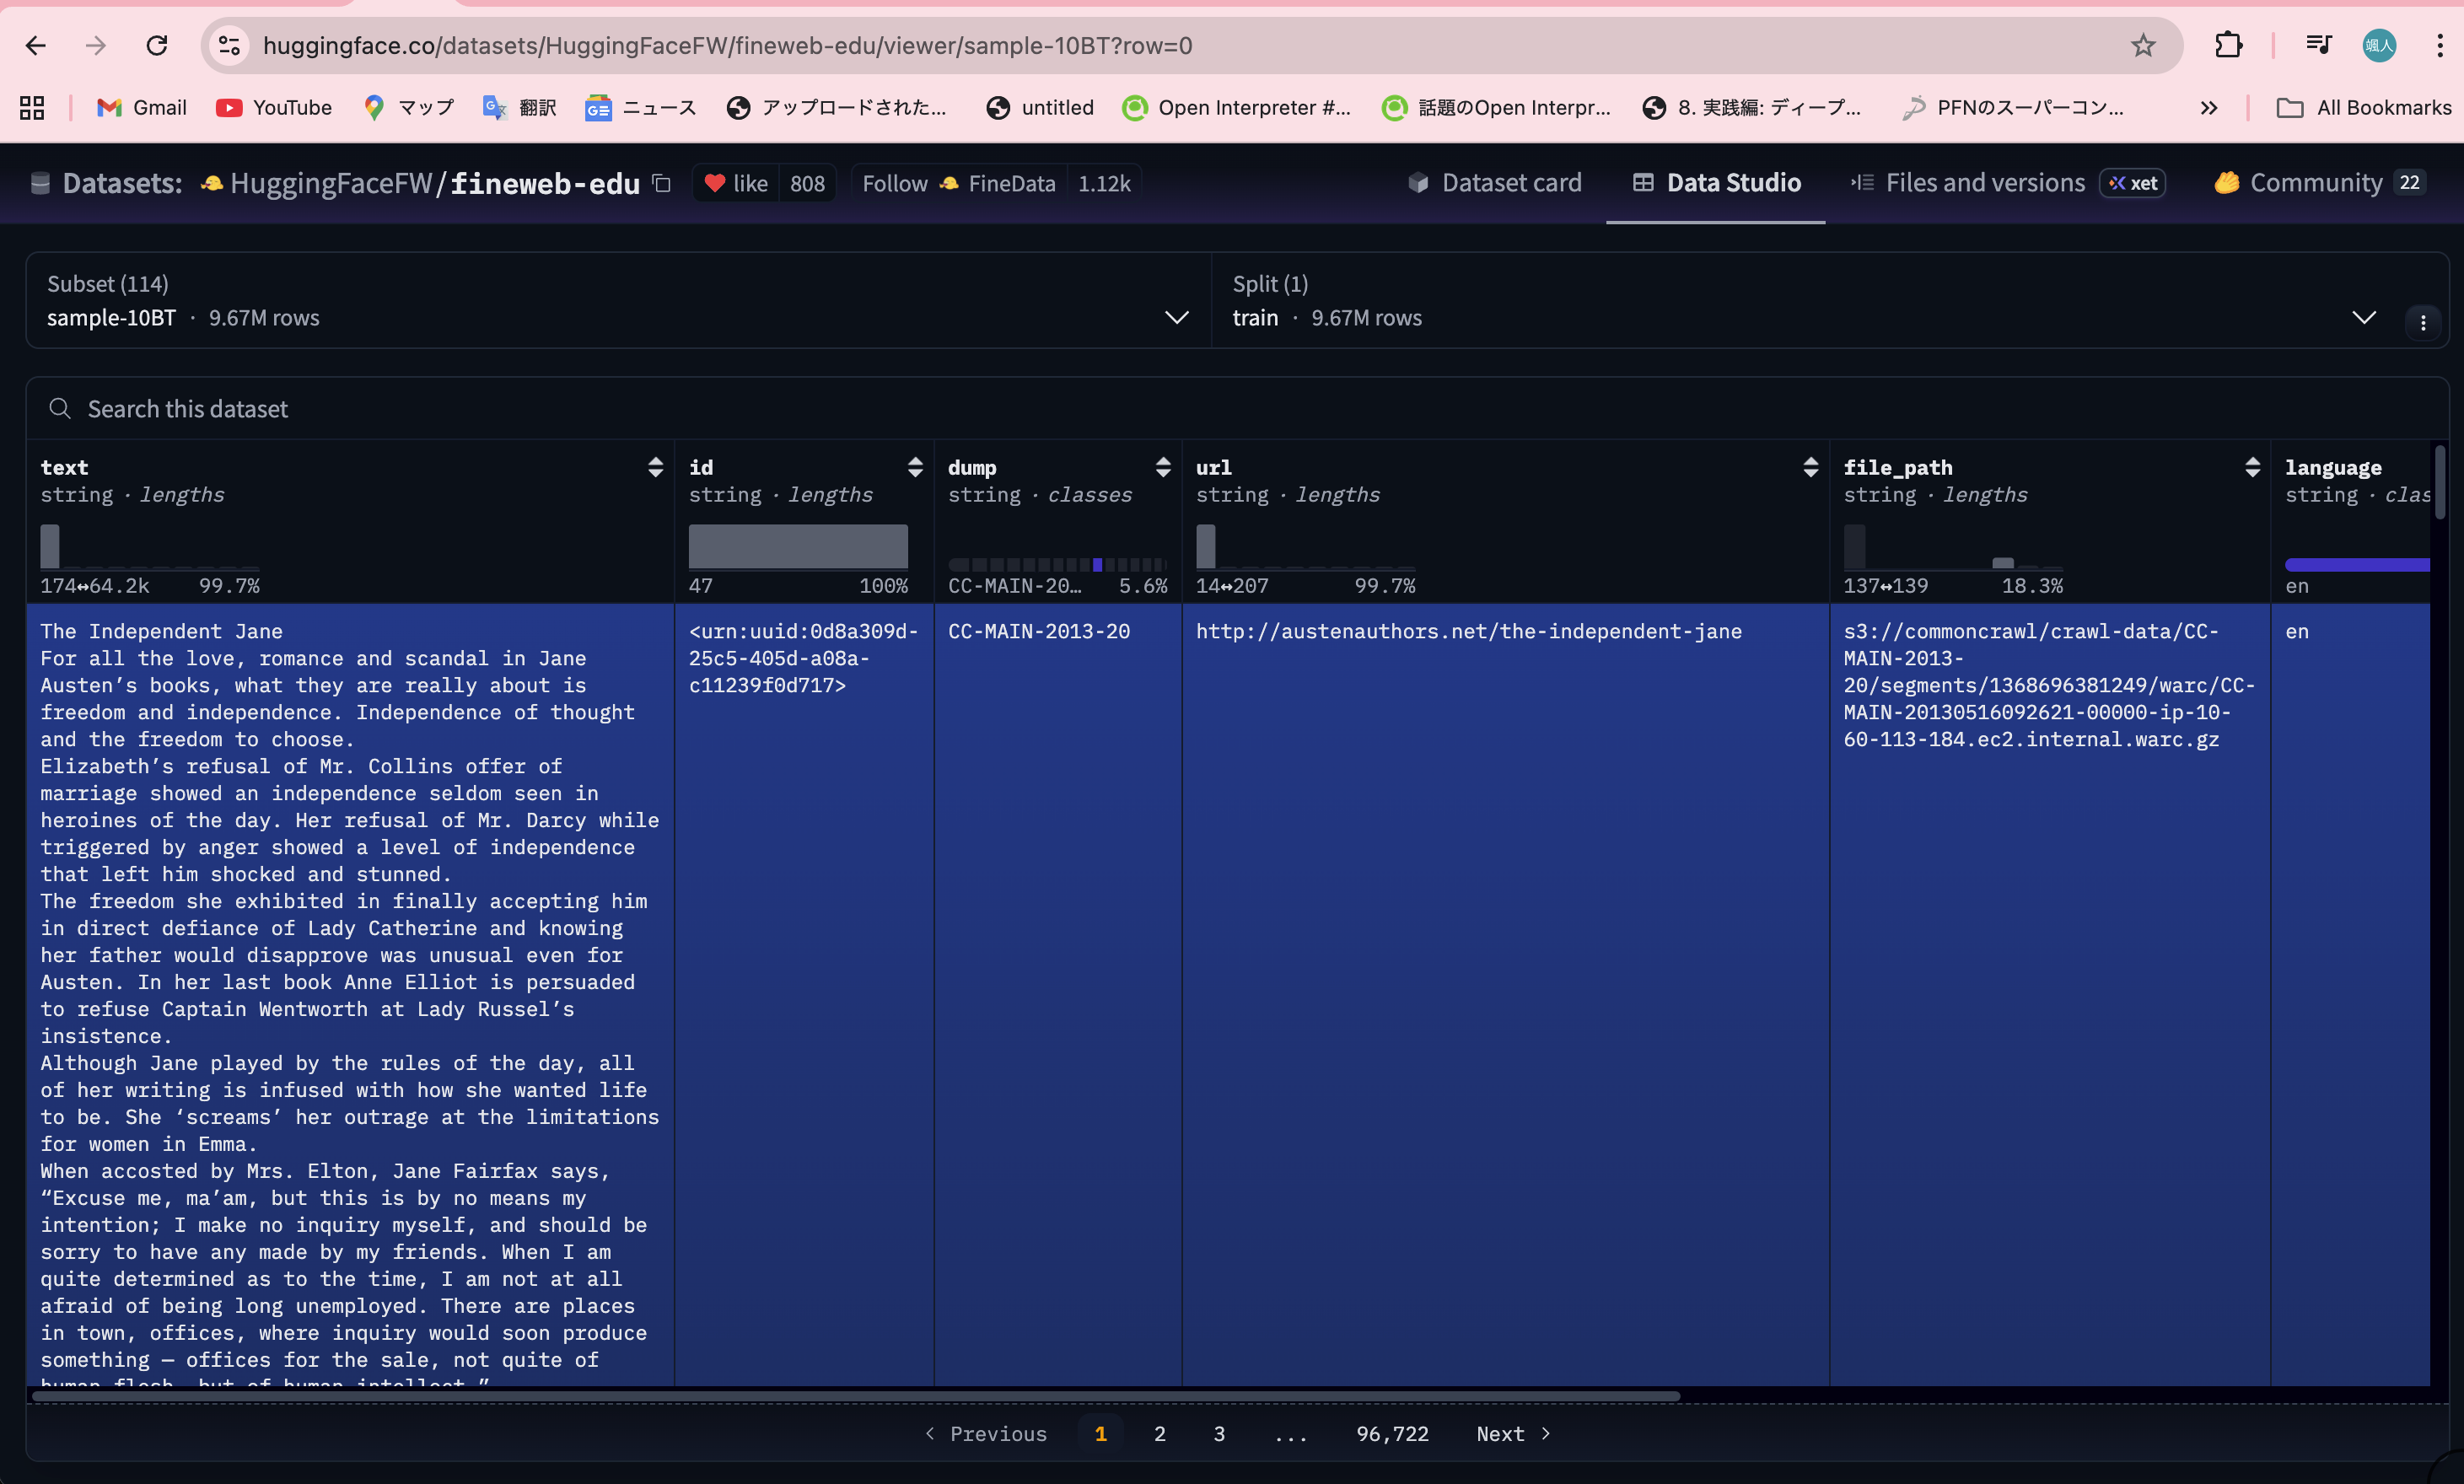

次の要素も見てみましょう。

In [ ]:
ds[1]

{'text': "Taking Play Seriously\nBy ROBIN MARANTZ HENIG\nPublished: February 17, 2008\nOn a drizzly Tuesday night in late January, 200 people came out to hear a psychiatrist talk rhapsodically about play -- not just the intense, joyous play of children, but play for all people, at all ages, at all times. (All species too; the lecture featured touching photos of a polar bear and a husky engaging playfully at a snowy outpost in northern Canada.) Stuart Brown, president of the National Institute for Play, was speaking at the New York Public Library's main branch on 42nd Street. He created the institute in 1996, after more than 20 years of psychiatric practice and research persuaded him of the dangerous long-term consequences of play deprivation. In a sold-out talk at the library, he and Krista Tippett, host of the public-radio program ''Speaking of Faith,'' discussed the biological and spiritual underpinnings of play. Brown called play part of the ''developmental sequencing of becoming a 

`ds`の要素数を調べてみます。通常のpythonのリストで要素数を調べてみる時と同じです。

In [ ]:
len(ds) # TODO: THINK_BY_YOURSEF

726000

このように、`ds`には、まとまった長さの文章が、何十万件と並んでいます。

たった1ファイルだけでこれだけの量ですから、FineWebの巨大さが分かると思います。

📦 データサイズまとめ

| データ名               | ディスクサイズ      | サンプル数     |
| ------------------ | ------------ | --------- |
| `000_0000.parquet` | **約2 GB** | **約70万**  |
| FineWeb-Edu 全体     | **約10 TB**   | **約15億**  |
| FineWeb 全体         | **約100 TB**  | **約259億** |

➡️ FineWeb 全体は `000_0000.parquet` の **数万倍**…！
スケール感バグってる……😳💥

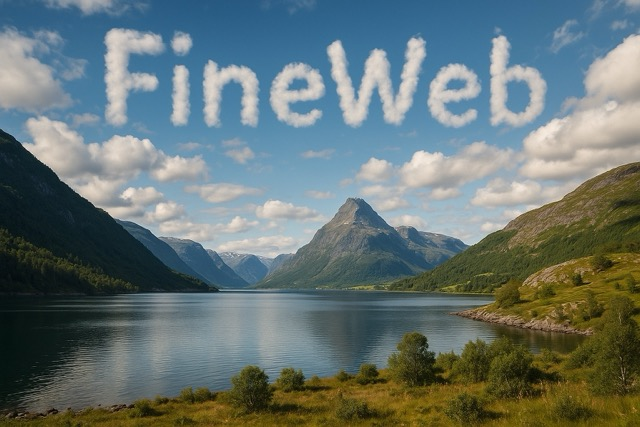

**Section 1: Common Crawl & FineWeb** <label><input type="checkbox"> Mark as Done</label>

### **Section 3: サンプルを結合する**

`ds` には、各データサンプルごとに `text` カラムがあり、そこに文章が格納されています。

Shakespeare の `input.txt` と同様に、今回はこれらのテキストをすべてまとめて **1つの大きな `fineweb.txt`** を作成します。

ただし、Shakespeare の `input.txt` が「一続きの長い物語」だったのに対し、今回は「短い文章が何十万と並んでいる」構成です。

そのため、文章の区切りには **「🄴」という特殊文字** を使います。

通常であれば `<|endoftext|>` のような特殊トークンを使いますが、現時点では 1 文字ずつ語彙に登録してトークン化しているため、自然な文章にほとんど出現しない **「🄴」** を区切り文字として利用し、複数の文章を無理なく連結します。

In [ ]:
# 文書境界
boundary = "🄴"
print(boundary)

🄴


読みやすさを保ちながら、意図がより自然に伝わるように整えました。

---

ところでみなさん、文章の境界を示す方法には実は **2通り** あります。どちらが良いと思いますか？

**A：🄴 を「現在の文章の終わり」として使う場合**

```plain
text1 🄴 text2 🄴 text3 🄴 ...
```

**B：🄴 を「前の文章の終わり」として使う場合（次の文章の始まりの前に置く）**

```plain
🄴 text1 🄴 text2 🄴 text3 ...
```

意外に思えるかもしれませんが、実は **B の方式を採用します**。

あまり重要ではないので理由は割愛します。結論だけ覚えておけばOKです：

**🄴 は B のように「文章の前に置く」のが一般的です。**


```python
with open("fineweb.txt", "w", encoding="utf-8") as f:
    for sample in ds:
        f.write(boundary + sample["text"])
```

* 🄴 text1 🄴 text2 🄴 text3 ... の形式で連結します。
* 1から書くのは難しいと思うので、タイピングしてください。

In [ ]:
with open("fineweb.txt", "w", encoding="utf-8") as f:
    for sample in ds:
        f.write(boundary + sample["text"]) # TODO: Typing is all you need (at least for now)

In [ ]:
# `fineweb.txt`のディスクサイズを計測するコマンド。通常の関数とは異なります。
!ls -lh fineweb.txt

-rw-r--r-- 1 root root 3.3G Nov 14 10:00 fineweb.txt


実は、この `fineweb.txt` は **ディスクサイズで約 3.3GB** もあります。

データのロードは文字のencodingなどの重たい処理を含んでいます。

このまま全データをロードしようとすると、**システム RAM が不足してクラッシュ**してしまいます。

そこで 約 70 万サンプルのうち、5万サンプルだけを使用した`nanofineweb.txt`を作成します。

```python
with open("nanofineweb.txt", "w", encoding="utf-8") as f:
    for i, sample in enumerate(ds):
        if i >= 50000:
            break
        f.write(boundary + sample["text"])
```

In [ ]:
with open("nanofineweb.txt", "w", encoding="utf-8") as f:
    for i, sample in enumerate(ds):
        if i >= 50000:
            break
        f.write(bounda ry + sample["text"]) # TODO: Typing is all you need (at least for now)

In [ ]:
# `nanofineweb.txt`のディスクサイズを計測するコマンド。通常の関数とは異なります。
!ls -lh nanofineweb.txt

-rw-r--r-- 1 root root 233M Nov 14 10:00 nanofineweb.txt


`nanofineweb.txt`について、最初の10,000文字を表示してみましょう。

In [ ]:
with open("nanofineweb.txt", "r", encoding="utf-8") as f: # TODO: 読み込みモードで`fineweb.txt`ファイルを開く
  text = f.read(10000) # TODO: THINK_BY_YOURSELF
  print(text)

🄴The Independent Jane
For all the love, romance and scandal in Jane Austen’s books, what they are really about is freedom and independence. Independence of thought and the freedom to choose.
Elizabeth’s refusal of Mr. Collins offer of marriage showed an independence seldom seen in heroines of the day. Her refusal of Mr. Darcy while triggered by anger showed a level of independence that left him shocked and stunned.
The freedom she exhibited in finally accepting him in direct defiance of Lady Catherine and knowing her father would disapprove was unusual even for Austen. In her last book Anne Elliot is persuaded to refuse Captain Wentworth at Lady Russel’s insistence.
Although Jane played by the rules of the day, all of her writing is infused with how she wanted life to be. She ‘screams’ her outrage at the limitations for women in Emma.
When accosted by Mrs. Elton, Jane Fairfax says,
“Excuse me, ma’am, but this is by no means my intention; I make no inquiry myself, and should be sorry to

**Section 3: サンプルを結合する** <label><input type="checkbox"> Mark as Done</label>

### **Section 4: モデルを学習する**

学習対象のファイル以外は完全に今までと同じです。

`Dataloader`クラスとモデルクラスを定義します。Chpater12と完全に同じです。

In [ ]:
class DataLoader:
    def __init__(self, text, config):
        self.config = config  # 設定オブジェクト
        chars = sorted(list(set(text)))  # ユニークな文字をソートする
        self.ctoi = {char: index for index, char in enumerate(chars)}
        self.itoc = {index: char for index, char in enumerate(chars)}

        # エンコードしてテンソルに変換する。
        # `__init__`外のメソッドや引数を呼ぶには`self.`が必要です。
        self.data = torch.tensor(self.encode(text), dtype=torch.long)

        # 訓練用と検証用に分割する。
        # 引数が指定されなくてもself.dataが使われます。
        self.train_data, self.val_data = self.split_data()

    def encode(self, text):
        # 文字列をインデックス列に変換します。self.で他のメソッドや引数を呼び出します。
        return [self.ctoi[c] for c in text]

    def decode(self, indices):
        return ''.join([self.itoc[i] for i in indices])

    def split_data(self):
        split_index = int(0.9 * len(self.data))  # データの90%を訓練用に分割するポイント。
        return self.data[:split_index], self.data[split_index:]

    def get_batch(self, split):
        data = self.train_data if split == 'train' else self.val_data
        start_indices = torch.randint(len(data) - self.config.input_sequence_length, (self.config.batch_size,)) # 抽出開始インデックスを生成する

        input_sequences = torch.stack([
            data[start_index:start_index + self.config.input_sequence_length]
            for start_index in start_indices
        ])
        target_sequences = torch.stack([
            data[start_index + 1:start_index + self.config.input_sequence_length + 1]
            for start_index in start_indices
        ])
        return input_sequences.to(self.config.device_type), target_sequences.to(self.config.device_type)

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = config.vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, config.vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

def generate_stream(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -model.config.input_sequence_length:]
            logits, _ = model(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] / temperature

            if top_k is not None:
                values, _ = torch.topk(last_logits, min(top_k, last_logits.size(-1)))
                last_logits = last_logits.masked_fill(last_logits < values[:, [-1]], float('-inf'))

            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(last_logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = False
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                last_logits = last_logits.masked_fill(indices_to_remove, float('-inf'))

            probs = F.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_indices = torch.cat((input_indices, next_token), dim=1)
            yield input_indices


def generate(model, input_indices, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
    generated_indices = input_indices
    for generated_indices in generate_stream(
        model,
        input_indices,
        max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    ):
        pass
    return generated_indices

class nanoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.embedding = EmbeddingModule(config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(config=config)
        self.criterion = nn.CrossEntropyLoss()

    # テキストを生成する
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

`Trainer`クラスを定義します。Chapter16と完全に同じです。

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # configで指定された回数だけtrain_stepを実行する。
        for step in range(1, self.config.total_steps + 1):
            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == self.config.evaluation_frequency:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

                print(
                    f"step {step:05d} | "
                    f"train loss {eval_loss['train']:.4f} | "
                    f"val loss {eval_loss['val']:.4f} | "
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                    f"tokens {total_seen_tokens:,} | "
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()

In [ ]:
# モデル設定を保存する設定クラス
class Config:
    batch_size = 16
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    vocab_size = 65
    total_steps = 10_000  # おおよそ1時間くらいかかる
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    learning_rate = 0.001  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 512  # 埋め込み層サイズ（特徴ベクトルの次元数）
    hidden_dim = 2048
    num_attention_heads = 8  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = Config()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

In [ ]:
# データを読み込む。ファイルが大きいほどシステムRAMを消費します。
with open("/content/nanofineweb.txt", 'r', encoding = 'utf-8') as f:
    text_data = f.read()
data_loader = DataLoader(text_data, config)

Webデータが対象となったことで、さまざまな文字が入ってきます。

In [ ]:
vocab_size = config.vocab_size
print(f"Vocab size: {vocab_size}")

Vocab size: 4162


語彙数はShakespearの`input.txt`の65から大幅に増加して、約4,000です。

なんでこんなに増えているのでしょうか？中身を見て見ましょう

In [ ]:
for i in range(vocab_size):
  char = data_loader.itoc[i] # TODO: indexからcharへ変換する。
  print(char)



 
!
"
#
$
%
&
'
(
)
*
+
,
-
.
/
0
1
2
3
4
5
6
7
8
9
:
;
<
=
>
?
@
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z
[
\
]
^
_
`
a
b
c
d
e
f
g
h
i
j
k
l
m
n
o
p
q
r
s
t
u
v
w
x
y
z
|
}
~
 
¡
¢
£
¤
¥
¦
§
¨
©
ª
«
¬
®
¯
°
±
²
³
´
µ
¶
·
¸
¹
º
»
¼
½
¾
¿
À
Á
Â
Ã
Ä
Å
Æ
Ç
È
É
Ê
Ë
Ì
Í
Î
Ï
Ð
Ñ
Ò
Ó
Ô
Õ
Ö
×
Ø
Ù
Ú
Û
Ü
Ý
Þ
ß
à
á
â
ã
ä
å
æ
ç
è
é
ê
ë
ì
í
î
ï
ð
ñ
ò
ó
ô
õ
ö
÷
ø
ù
ú
û
ü
ý
þ
ÿ
Ā
ā
Ă
ă
Ą
ą
Ć
ć
ĉ
Č
č
Ď
ď
Đ
đ
Ē
ē
ĕ
Ė
ė
ę
Ě
ě
ĝ
Ğ
ğ
Ġ
ġ
ĥ
ħ
ĩ
Ī
ī
ĭ
į
İ
ı
ĵ
ķ
ĺ
Ľ
ľ
Ł
ł
ń
ņ
ň
ŉ
ŋ
Ō
ō
ŏ
ő
Œ
œ
Ř
ř
Ś
ś
ŝ
Ş
ş
Š
š
Ţ
ţ
Ť
ť
ũ
Ū
ū
ŭ
ů
ű
ų
ŵ
ŷ
Ÿ
Ź
ź
Ż
ż
Ž
ž
ſ
Ǝ
ƒ
ƕ
ƛ
ơ
ư
ǂ
ǃ
ǎ
ǐ
ǒ
ǔ
ǖ
ǜ
ǝ
ǣ
Ǧ
ǧ
ǫ
ǰ
ǵ
ǿ
ȋ
Ș
ș
ț
Ȝ
ȝ
ȟ
ȧ
ȳ
ȶ
ɐ
ɑ
ɒ
ɔ
ɕ
ɖ
ə
ɚ
ɛ
ɜ
ɝ
ɟ
ɡ
ɢ
ɣ
ɤ
ɨ
ɪ
ɫ
ɬ
ɮ
ɯ
ɰ
ɱ
ɲ
ɳ
ɴ
ɶ
ɸ
ɹ
ɻ
ɽ
ɾ
ʀ
ʁ
ʂ
ʃ
ʉ
ʊ
ʋ
ʌ
ʏ
ʒ
ʔ
ʕ
ʙ
ʜ
ʟ
ʢ
ʤ
ʰ
ʲ
ʷ
ʹ
ʺ
ʻ
ʼ
ʽ
ʾ
ʿ
ˆ
ˇ
ˈ
ˉ
ˊ
ˌ
ː
ˑ
˘
˚
˛
˜
˝
ˠ
ˤ
̀
́
̂
̃
̄
̅
̈
̑
̓
̙
̚
̜
̝
̞
̟
̠
̣
̥
̧
̩
̪
̯
̳
̴
̶
̹
͞
͡
ͦ
͵
ͻ
΄
Ά
Έ
Ή
Ό
ΐ
Α
Β
Γ
Δ
Ε
Ζ
Η
Θ
Ι
Κ
Λ
Μ
Ν
Ξ
Ο
Π
Ρ
Σ
Τ
Υ
Φ
Χ
Ψ
Ω
ά
έ
ή
ί
α
β
γ
δ
ε
ζ
η
θ
ι
κ
λ
μ
ν
ξ
ο
π
ρ
ς
σ
τ
υ
φ
χ
ψ
ω
ϊ
ϋ
ό
ύ
ώ
ϑ
Ϛ
Ϝ
Ђ
І
А
Б
В
Г
Д
Е
Ж
З
И
Й
К
Л
М
Н
О
П
Р
С


🙄

Webデータなので、英語のアルファベットだけではなく、様々な国の言語の文字や絵文字が含まれています。

そのため、語彙数は非常に大きくなります。

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

17.13261 M parameters


`Config`が同じでも、パラメータ数が`input.txt`のときよりも増えます。

**パラメータ数の変化。`Config`は同一とする。**

| ケース       | 総パラメータ    |
| --------- | --------- |
| `input.txt` | **約 13M** |
| `nanofineweb.txt`        | **約 17M** |

え、じゃあ計算コスト爆増？と、思うかもしれませんが、実はそうではありません。

2つの異なる部分でパラメータ数が増えています。

| 層                     | パラメータ増加 | 計算コスト                       |
| --------------------- | ------- | --------------------------- |
| Token Embedding   | 語彙数に比例  | ほぼ増えない(`nn.Embedding`は参照のみ) |
| 出力層（Vocabulary Logits） | 語彙数に比例  | 増える(`nn.Linear`での順伝播が影響)                 |

詳細は割愛しますが、`nn.Embedding`は参照のみであるため、語彙数が増えても計算コストはほとんど増加しません。

このような「埋め込みパラメータ」は計算コストへの影響がほぼ無視できます。

計算コストに影響があるのは`nn.Linear`などの「非埋め込みパラメータ」です。

そのため、パラメータ数は増加しましたが、計算コストの増加は出力層のみであり、影響は限定的です。

### 🚀 学習スタート！

いよいよ`nanofineweb.txt`で学習を開始します。

今回も **15 GB RAM の T4 GPU** を使用し、
`batch size = 16`、`total steps = 10,000` の設定で進めます。

この条件だと、**学習完了までにおよそ58分**ほどかかります😇

正直、かなりヒマです…。

[FineWebの論文](https://arxiv.org/pdf/2406.17557)を読むのもアリです👍




In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===
step 00000 | train loss 8.4140 | val loss 8.4169 | tok/s None | tokens 0 | time 0.00s
step 00100 | train loss 2.5920 | val loss 2.5970 | tok/s 26157 | tokens 819,200 | time 31.32s
step 00200 | train loss 2.5425 | val loss 2.5706 | tok/s 25137 | tokens 1,638,400 | time 63.91s
step 00300 | train loss 2.5736 | val loss 2.5706 | tok/s 25900 | tokens 2,457,600 | time 95.54s
step 00400 | train loss 2.5528 | val loss 2.5503 | tok/s 25626 | tokens 3,276,800 | time 127.50s
step 00500 | train loss 2.5322 | val loss 2.5114 | tok/s 25707 | tokens 4,096,000 | time 159.37s
step 00600 | train loss 2.3653 | val loss 2.4045 | tok/s 25674 | tokens 4,915,200 | time 191.28s
step 00700 | train loss 2.2604 | val loss 2.2696 | tok/s 25815 | tokens 5,734,400 | time 223.01s
step 00800 | train loss 2.2378 | val loss 2.2344 | tok/s 24663 | tokens 6,553,600 | time 256.22s
step 00900 | train loss 2.2035 | val loss 2.2103 | tok/s 25305 | tokens 7,372,800 | time 288.60s
step 01000 | train los

横軸を`Step`、縦軸を`Loss`として`matplotlib`を使って描画しましょう。

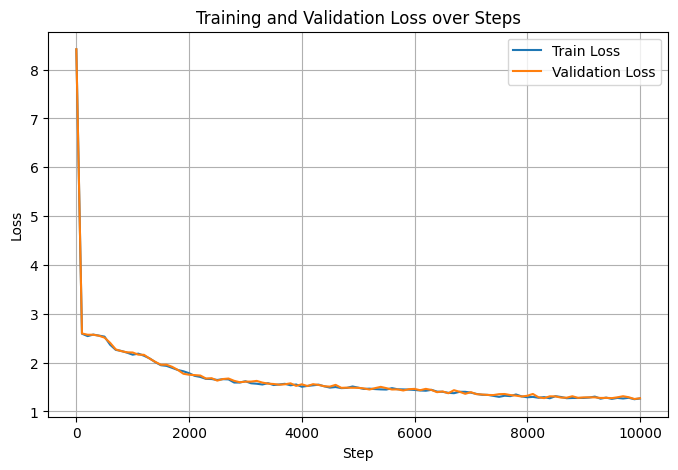

In [ ]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')
plt.plot(trainer.steps, trainer.val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

![head_bouding_cat](https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExajJmN3pmZGpnYmxnMzg4ZGhoZWQydTJkeG9kZWk1dHZpeXlhdWN4ayZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/hDYz2avbyKw9cYwDbP/giphy.gif)


検証誤差も訓練誤差もきれいに下がり続けています。

潤沢なデータのおかげで過学習することなく、モデルがしっかり学習していますね。

推論してみましょう。

果たしてその性能はいかに、、?


In [ ]:
# 推論もやってみる
# 評価モードに切り替え。ドロップアウトを無効化する。
model.eval()
print("Model set to eval mode")

Model set to eval mode


In [ ]:
prompt = "New York is"
print(f"\n入力プロンプト: {prompt}")

# トークナイズしてテンソル化
encoded = data_loader.encode(prompt) # テキストをIDにエンコード
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
print_formatted_tensor(encoded_tensor)


入力プロンプト: New York is
encoded [47, 70, 88, 1, 58, 80, 83, 76, 1, 74, 84]
Tensor Size: [11]
tensor([
         47.00,  70.00,  88.00,   1.00,  58.00,  80.00,  83.00,  76.00,   1.00,  74.00,  84.00
       ])
Tensor Size: [1, 11]
tensor([
         [ 47.00,  70.00,  88.00,   1.00,  58.00,  80.00,  83.00,  76.00,   1.00,  74.00,  84.00]
       ])
Tensor Size: [1, 11]
tensor([
         [ 47.00,  70.00,  88.00,   1.00,  58.00,  80.00,  83.00,  76.00,   1.00,  74.00,  84.00]
       ])


In [ ]:
# テキスト生成
generated_text = generate(model, encoded_tensor, max_new_tokens=512)

In [ ]:
decoded_text = data_loader.decode(generated_text[0].tolist())
print(decoded_text)

New York is caused by different against Kandnot Monastoms Andrew York to Organization. But build by Dr. 1 ff Warbert Wikipedias, authorization in Version for H. 2009, 1078. He absorbed educators to Milia. Daning Riverge-rid practical growing direction relationships and the cavity of Randnot March 14, 2018.
Many Associations and described highlight plan for the cave built. Fatemix of Reliefs Education of Egyptianmental metabolic or efficient. Shocks wanted British Aedrew Park.
World Hritish attracts Transplanted Indefi


🧐...まあうん。

なんとも言えない品質だと思います。

難しい単語やつづりをスペルミスなく書けている割には、文脈が支離滅裂です。

限られた計算資源でWebデータを学習させるのには限界があります。

今回は10,000stepでしたが、さらに計算資源を投入して学習させるとどうなるでしょう？

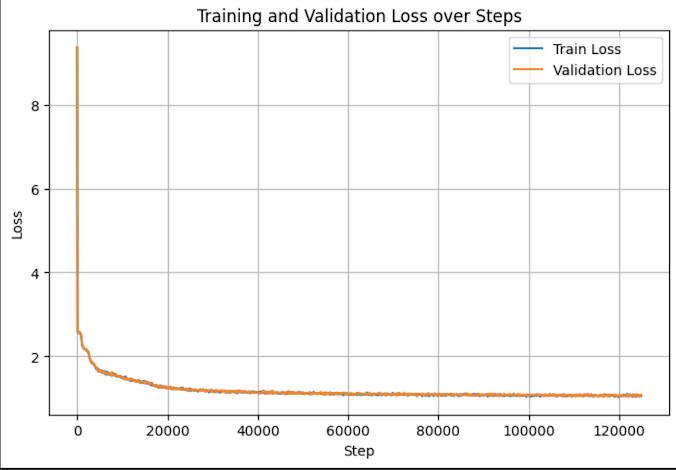

上記は入力データを10倍に増やした上で、同じconfigで、今回の10,000ステップのおよそ10倍のステップ数で学習させた時のログです。（正確には124,900stepまで訓練して打ち切り。）

50,000ステップを過ぎる頃には、検証誤差も訓練誤差も1.0~1.1で両方ともほとんど下がらなくなる`loss plateau`の状態になっています。

なお、生成したテキストの品質を見てみましょう。(step 124900, 512 tokens)

```plain
New York is location slot of art, countenance, condemning of the Land Bustling and other regional troops. As 30 percent of production slots in time are renewed.
In these articles the extreme art of dramatic property that isSupreme Court refers to the regional retail knowledge of both privates and buildings of the Holygen Language as with the Holygenic Council of the Court begins as most active forces for New York including May 15. In 02/6, all in their five Yorkshire Articles entered into the eastern Orthodoxy divisi...
```

🤨 ...ぶっちゃけ微妙！

だと思います。とりあえずこの原始的な手法で達成できる最終性能がこれだということです。

これからはどんどんモデルを改良していきます💪

一番楽しいパートの幕開けです。

**Section 4: モデルを学習する** <label><input type="checkbox"> Mark as Done</label>

### **Section 5: Google Driveへの保存**

今回もT4 GPUをたっぷり使って学習してるので、学習ログはきちんと保管しましょう。

おすすめはGoole Driveです。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 学習済み trainer からログをまとめる
results = {
    "step": trainer.steps,
    "train_loss": trainer.train_losses,
    "val_loss": trainer.val_losses,
    "total_seen_tokens": trainer.total_seen_tokens_list,
    "total_train_time": trainer.total_train_time_list,
}

print(results)

{'step': [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000], 'train_loss': [8.414012813568116, 2.591963267326355, 2.5425098657608034, 2.573576474189758, 2.552821660041809, 2.532231330871582, 2.3653178215026855, 2.2604113578796388, 2.237786078453064, 2.2035167694091795, 2.1619197845458986, 2.1832939624786376, 2.1406471967697143, 2.0858718276023867, 2.0097784399986267, 1.9465094327926635, 1.9331477522850036, 1.892325508594513, 1.848755383491516, 1.82225

```python
関数: pd.DataFrame
引数: results（辞書やリストなどのデータ構造）
```


In [ ]:
import pandas as pd
# pandas の DataFrame に変換
df = pd.DataFrame(results) # TODO: 関数(引数)

In [ ]:
df

,step,train_loss,val_loss,total_seen_tokens,total_train_time
0,0,8.414013,8.416873,0,0.000000
1,100,2.591963,2.596959,819200,31.318496
2,200,2.542510,2.570640,1638400,63.906854
3,300,2.573576,2.570639,2457600,95.535648
4,400,2.552822,2.550306,3276800,127.502890
...,...,...,...,...,...
96,9600,1.276661,1.289148,78643200,3118.240993
97,9700,1.264678,1.311500,79462400,3151.297081
98,9800,1.279484,1.291091,80281600,3183.178534
99,9900,1.250147,1.254757,81100800,3216.788800


```python
関数: os.makedirs
引数: dir_path, exist_ok=True
```

* `os.makedirs(dir_path)`は、指定したパスのディレクトリを作成します。
* `exist_ok=True`を指定することで、すでにフォルダが存在していてもエラーにならずにスキップされます。


In [ ]:
# 保存先のフォルダを作成する
import os
dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter17"
os.makedirs(dir_path, exist_ok=True) # TODO: 関数(引数)

In [ ]:
# csvファイルとして保存する先のパスを指定する。
save_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter17/training_logs.csv"

```python
インスタンス: df（pandasのDataFrame）
メソッド: to_csv
引数: save_path, index=False
```

* `df.to_csv(save_path, index=False)` により、`df`の内容をCSVファイルとして保存します。
* `index=False` を指定すると、DataFrameの行番号（インデックス）はCSVに書き込まれません。

In [ ]:
# CSVとして保存
df.to_csv(save_path, index=False) # TODO: インスタンス.メソッド(引数)
print(f"✅ CSV saved to: {save_path}")

✅ CSV saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter17/training_logs.csv


#### 📂 ログファイルの確認方法

[Google Drive](https://drive.google.com/drive/u/0/home) を開いて確認してください。

作成したフォルダ **`nanoGPT_logs/Chapter17`** の中に、
CSV形式のログファイルが作成されているはずです。

---

⚠️ **注意：**
Google Drive のマウントに失敗したまま進めると、
フォルダやファイルは`drive`という名前の **Colab のローカル環境** のフォルダに保存されます。Google Drive上にはありません。

その場合は再度Driveをマウントしてください。

---


**`Check Point`** <label><input type="checkbox">Google Drive上のcsvファイルを確認した<label>

次に、モデル情報を記したconfigインスタンスについても、config.jsonとして保存しましょう。

```python
関数: vars
引数: config.__class__
```

* `vars(config.__class__)` は、`config` インスタンスのクラス（`config.__class__`）が持つ属性を辞書形式で取得します。
* `vars` は `__dict__` にアクセスするための推奨される組み込み関数です。
* 結果として、`{属性名: 属性値, ...}` という形式の辞書が得られます。

In [ ]:
# クラス属性を辞書化
config_class_dict = vars(config.__class__) # TODO: 関数(引数)
print(config_class_dict)

{'__module__': '__main__', 'batch_size': 16, 'input_sequence_length': 512, 'total_steps': 10000, 'device_type': 'cuda', 'evaluation_frequency': 100, 'learning_rate': 0.001, 'evaluation_loops': 10, 'embedding_dim': 512, 'hidden_dim': 2048, 'num_attention_heads': 8, 'layer_count': 4, 'dropout_rate': 0.1, 'random_seed_value': 1337, '__dict__': <attribute '__dict__' of 'Config' objects>, '__weakref__': <attribute '__weakref__' of 'Config' objects>, '__doc__': None}


```python
元の変数: config_class_dict
メソッド: items
引数：なし

新しい変数 = 元の変数.メソッド(引数)
```

* `.items()` を使うことで、クラス属性の名前（キー）とその値を1つずつ処理できる形式になる。


In [ ]:
# 辞書の (key, value) ペアを取得
config_dict_items = config_class_dict.items() # TODO: 新しい変数 = 元の変数.メソッド(引数)
print(config_dict_items)

dict_items([('__module__', '__main__'), ('batch_size', 16), ('input_sequence_length', 512), ('total_steps', 10000), ('device_type', 'cuda'), ('evaluation_frequency', 100), ('learning_rate', 0.001), ('evaluation_loops', 10), ('embedding_dim', 512), ('hidden_dim', 2048), ('num_attention_heads', 8), ('layer_count', 4), ('dropout_rate', 0.1), ('random_seed_value', 1337), ('__dict__', <attribute '__dict__' of 'Config' objects>), ('__weakref__', <attribute '__weakref__' of 'Config' objects>), ('__doc__', None)])


`__module__`という余計なキーが混ざっているので、除去します。

In [ ]:
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
}

print(config_dict)

{'batch_size': 16, 'input_sequence_length': 512, 'total_steps': 10000, 'device_type': 'cuda', 'evaluation_frequency': 100, 'learning_rate': 0.001, 'evaluation_loops': 10, 'embedding_dim': 512, 'hidden_dim': 2048, 'num_attention_heads': 8, 'layer_count': 4, 'dropout_rate': 0.1, 'random_seed_value': 1337}


```python
関数: os.path.join
引数: dir_path, "model_config.json"
```

* `os.path.join()` は、複数のパス要素を結合して、プラットフォームに依存しないファイルパスを作成する関数。
* たとえば Windows では `\`、Unix系では `/` を使ってパスを正しく構築してくれます。
* この場合、`dir_path` ディレクトリ内の `"model_config.json"` ファイルへのパスを作成。

In [ ]:
# 保存先のファイルパスを作成する。
# dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter17"
config_path = os.path.join(dir_path, "model_config.json") # TODO: 関数(引数)
print(config_path)

/content/drive/MyDrive/nanoGPT_logs/Chapter17/model_config.json


```python
関数: json.dump
引数: config_dict, f
```

* `config_dict` をファイル `f` に JSON形式で書き込み。

In [ ]:
import json
# ファイルを「書き込みモード(w)」で開き、変数`f`で操作できるようにする
with open(config_path, "w") as f:
    json.dump(config_dict, f) # TODO: 関数(引数)

print(f"✅ Config saved to: {config_path}")

✅ Config saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter17/model_config.json


**Section 5: Google Driveへの保存** <label><input type="checkbox"> Mark as Done</label>

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 17: データセットを大きくする** <label><input type="checkbox"> Mark as Done</label>